In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
path_to_dataset = "../../public_data"

# Confidence Estimation

In [13]:
import pathlib
import cdmetadl

PROJECT_DIR = pathlib.Path(cdmetadl.__file__).parent.parent

In [14]:
import pathlib

import cdmetadl.helpers.general_helpers
import cdmetadl.dataset

dataset_path = pathlib.Path(path_to_dataset)
dataset_info_dict = cdmetadl.helpers.general_helpers.check_datasets(dataset_path, ["AWA"])

dataset = cdmetadl.dataset.ImageDataset("-", dataset_info_dict["AWA"])

In [15]:
import cdmetadl.samplers

n_way_sampler = cdmetadl.samplers.ValueSampler(value=5)
k_shot_sampler = cdmetadl.samplers.ValueSampler(value=4)

task = dataset.generate_task(n_way_sampler, k_shot_sampler, query_size=4)

In [16]:
import cdmetadl.helpers.general_helpers

model_module = cdmetadl.helpers.general_helpers.load_module_from_path(PROJECT_DIR / "baselines/maml/model.py")


## Pseudo Confidence Estimation

[0.0, 0.29973602294921875, 0.380477637052536, 0.2296193391084671, 0.0]


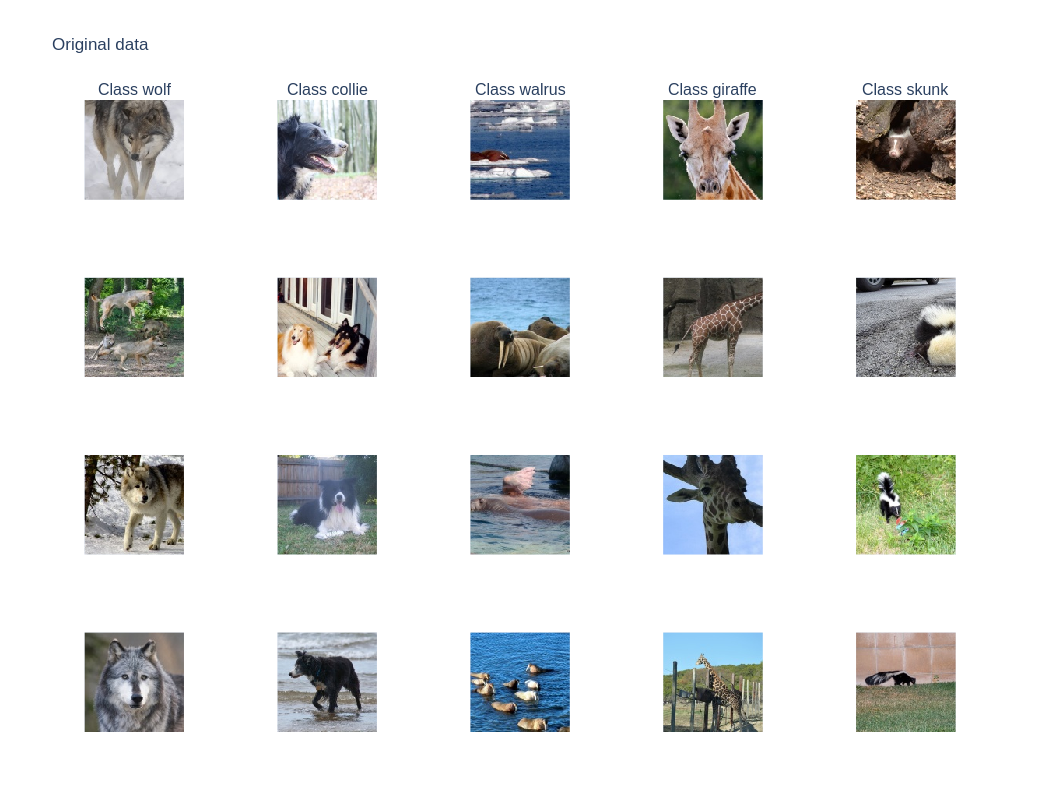

In [17]:
import cdmetadl.confidence
import cdmetadl.notebooks.helpers

learner = model_module.MyLearner()
learner.load("../../output/final/training/dropout_30_k_5/maml/cross-domain/model")

confidence_estimator = cdmetadl.confidence.PseudoConfidenceEstimator()
_, confidence_scores = confidence_estimator.estimate(learner, task.support_set)
print(confidence_scores)

fig = cdmetadl.notebooks.helpers.show_images_grid_plotly(task.support_set, True)

## Monte Carlo Dropout Confidence Estimation

In [18]:
import cdmetadl.confidence
import cdmetadl.notebooks.helpers
confidence_estimator = cdmetadl.confidence.MCDropoutConfidenceEstimator(num_samples=1000)

100%|██████████| 1000/1000 [00:03<00:00, 282.02it/s]


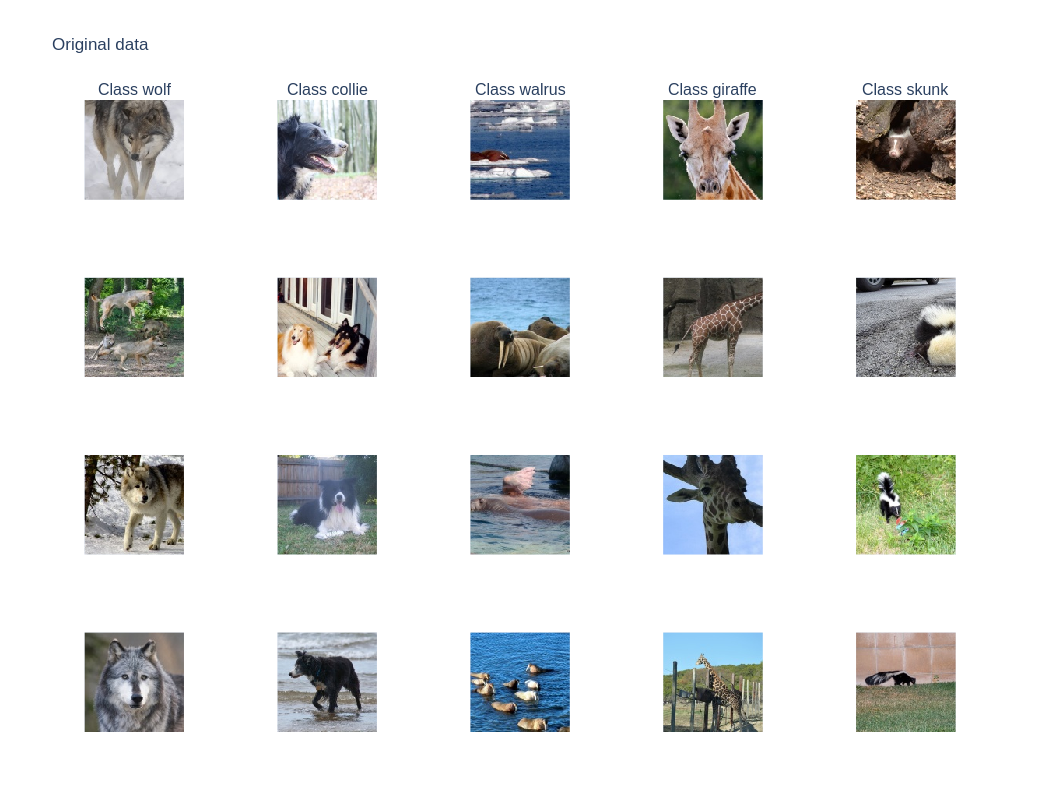

[1.2629462e-06 1.3445253e-06 2.3502112e-06 1.4476325e-05 1.2357256e-05]


In [19]:
learner = model_module.MyLearner()
learner.load("../../output/final/training/dropout_30_k_5/maml/cross-domain/model")
learner.T = 2_000
_, confidence_scores = confidence_estimator.estimate(learner, task.support_set)

fig = cdmetadl.notebooks.helpers.show_images_grid_plotly(task.support_set, True)

print(confidence_scores)

In [20]:
from tqdm import tqdm
import numpy as np
import pandas as pd

samples_conf_scores = 10

conf_scores = []
for T in [10, 20, 30, 35]:
    print(f"Test with T={T}")
    conf_scores = []

    for sample in tqdm(range(samples_conf_scores)):
        learner = model_module.MyLearner()
        learner.load("../../output/final/training/dropout_30_k_5/maml/cross-domain/model")
        learner.T = T
        conf_scores.append(confidence_estimator.estimate(learner, task.support_set)[1])
    
    conf_scores = np.array(conf_scores)
    avg_correlation = (sum(np.corrcoef(conf_scores).flatten()) - samples_conf_scores)/(samples_conf_scores**2 - samples_conf_scores)

    print(f"correlation for T={T}: {round(avg_correlation, 5)}, given just np.mean(class_predictions.var(axis=0), axis=0)")
    print(pd.Series(conf_scores.argmax(axis=1)).value_counts())
    print(pd.Series(conf_scores.argmin(axis=1)).value_counts())
    print(pd.DataFrame(conf_scores).rank(axis=1).mean())

Test with T=10


100%|██████████| 10/10 [00:39<00:00,  3.93s/it]


correlation for T=10: 0.64564, given just np.mean(class_predictions.var(axis=0), axis=0)
3    9
0    1
Name: count, dtype: int64
4    4
2    3
0    2
1    1
Name: count, dtype: int64
0    2.9
1    3.5
2    2.2
3    4.7
4    1.7
dtype: float64
Test with T=20


100%|██████████| 10/10 [00:42<00:00,  4.29s/it]


correlation for T=20: 0.88791, given just np.mean(class_predictions.var(axis=0), axis=0)
3    10
Name: count, dtype: int64
2    9
1    1
Name: count, dtype: int64
0    2.9
1    2.7
2    1.1
3    5.0
4    3.3
dtype: float64
Test with T=30


100%|██████████| 10/10 [00:40<00:00,  4.05s/it]


correlation for T=30: 0.95299, given just np.mean(class_predictions.var(axis=0), axis=0)
3    10
Name: count, dtype: int64
2    9
1    1
Name: count, dtype: int64
0    3.2
1    2.3
2    1.2
3    5.0
4    3.3
dtype: float64
Test with T=35


100%|██████████| 10/10 [00:44<00:00,  4.41s/it]

correlation for T=35: 0.97589, given just np.mean(class_predictions.var(axis=0), axis=0)
3    10
Name: count, dtype: int64
2    8
1    2
Name: count, dtype: int64
0    2.8
1    2.0
2    1.2
3    5.0
4    4.0
dtype: float64
